In [2]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import joblib

from sklearn.model_selection import train_test_split
from sklearn.compose import ColumnTransformer
from sklearn.preprocessing import OneHotEncoder
from sklearn.pipeline import Pipeline
from sklearn.ensemble import RandomForestRegressor
from sklearn.metrics import mean_absolute_error, r2_score

In [3]:
df = pd.read_csv("Laptop.csv")

df.head()

,Unnamed: 0.1,Unnamed: 0,brand,name,price,spec_rating,processor,CPU,Ram,Ram_type,ROM,ROM_type,GPU,display_size,resolution_width,resolution_height,OS,warranty
0,0,0,HP,Victus 15-fb0157AX Gaming Laptop,49900,73.000000,5th Gen AMD Ryzen 5 5600H,"Hexa Core, 12 Threads",8GB,DDR4,512GB,SSD,4GB AMD Radeon RX 6500M,15.6,1920.0,1080.0,Windows 11 OS,1
1,1,1,HP,15s-fq5007TU Laptop,39900,60.000000,12th Gen Intel Core i3 1215U,"Hexa Core (2P + 4E), 8 Threads",8GB,DDR4,512GB,SSD,Intel UHD Graphics,15.6,1920.0,1080.0,Windows 11 OS,1
2,2,2,Acer,One 14 Z8-415 Laptop,26990,69.323529,11th Gen Intel Core i3 1115G4,"Dual Core, 4 Threads",8GB,DDR4,512GB,SSD,Intel Iris Xe Graphics,14.0,1920.0,1080.0,Windows 11 OS,1
3,3,3,Lenovo,Yoga Slim 6 14IAP8 82WU0095IN Laptop,59729,66.000000,12th Gen Intel Core i5 1240P,"12 Cores (4P + 8E), 16 Threads",16GB,LPDDR5,512GB,SSD,Intel Integrated Iris Xe,14.0,2240.0,1400.0,Windows 11 OS,1
4,4,4,Apple,MacBook Air 2020 MGND3HN Laptop,69990,69.323529,Apple M1,Octa Core (4P + 4E),8GB,DDR4,256GB,SSD,Apple M1 Integrated Graphics,13.3,2560.0,1600.0,Mac OS,1


In [4]:
print(df.shape)
print(df.columns)
print(df.info())
print(df.isnull().sum())

(893, 18)
Index(['Unnamed: 0.1', 'Unnamed: 0', 'brand', 'name', 'price', 'spec_rating',
       'processor', 'CPU', 'Ram', 'Ram_type', 'ROM', 'ROM_type', 'GPU',
       'display_size', 'resolution_width', 'resolution_height', 'OS',
       'warranty'],
      dtype='str')
<class 'pandas.DataFrame'>
RangeIndex: 893 entries, 0 to 892
Data columns (total 18 columns):
 #   Column             Non-Null Count  Dtype  
---  ------             --------------  -----  
 0   Unnamed: 0.1       893 non-null    int64  
 1   Unnamed: 0         893 non-null    int64  
 2   brand              893 non-null    str    
 3   name               893 non-null    str    
 4   price              893 non-null    int64  
 5   spec_rating        893 non-null    float64
 6   processor          893 non-null    str    
 7   CPU                893 non-null    str    
 8   Ram                893 non-null    str    
 9   Ram_type           893 non-null    str    
 10  ROM                893 non-null    str    
 11  ROM_type

In [5]:
# Missing Values
print(df.isnull().sum())

# Duplicate Values
print("Duplicate Rows:", df.duplicated().sum())


Unnamed: 0.1         0
Unnamed: 0           0
brand                0
name                 0
price                0
spec_rating          0
processor            0
CPU                  0
Ram                  0
Ram_type             0
ROM                  0
ROM_type             0
GPU                  0
display_size         0
resolution_width     0
resolution_height    0
OS                   0
warranty             0
dtype: int64
Duplicate Rows: 0


In [6]:
# Summary Statistics
print(df.describe())

# Dataset Information
print(df.info())

       Unnamed: 0.1   Unnamed: 0          price  spec_rating  display_size  \
count    893.000000   893.000000     893.000000   893.000000    893.000000   
mean     467.135498   521.382979   79907.409854    69.379026     15.173751   
std      270.209769   299.916605   60880.043823     5.541555      0.939095   
min        0.000000     0.000000    9999.000000    60.000000     11.600000   
25%      235.000000   265.000000   44500.000000    66.000000     14.000000   
50%      467.000000   531.000000   61990.000000    69.323529     15.600000   
75%      702.000000   784.000000   90990.000000    71.000000     15.600000   
max      930.000000  1019.000000  450039.000000    89.000000     18.000000   

       resolution_width  resolution_height    warranty  
count        893.000000         893.000000  893.000000  
mean        2035.393057        1218.324748    1.079507  
std          426.076009         326.756883    0.326956  
min         1080.000000         768.000000    0.000000  
25%         

In [7]:
df = df.drop_duplicates()
df = df.dropna()

print(df.shape)

(893, 18)


In [8]:
X = df.drop("price", axis=1)
y = df["price"]

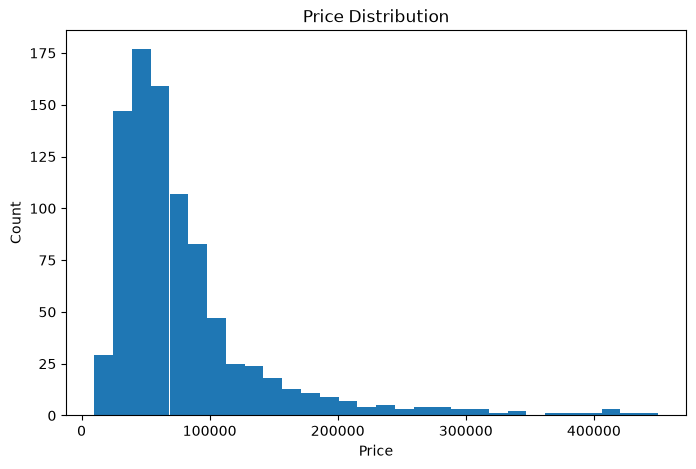

In [9]:
plt.figure(figsize=(8,5))
plt.hist(df["price"], bins=30)
plt.title("Price Distribution")
plt.xlabel("Price")
plt.ylabel("Count")
plt.show()

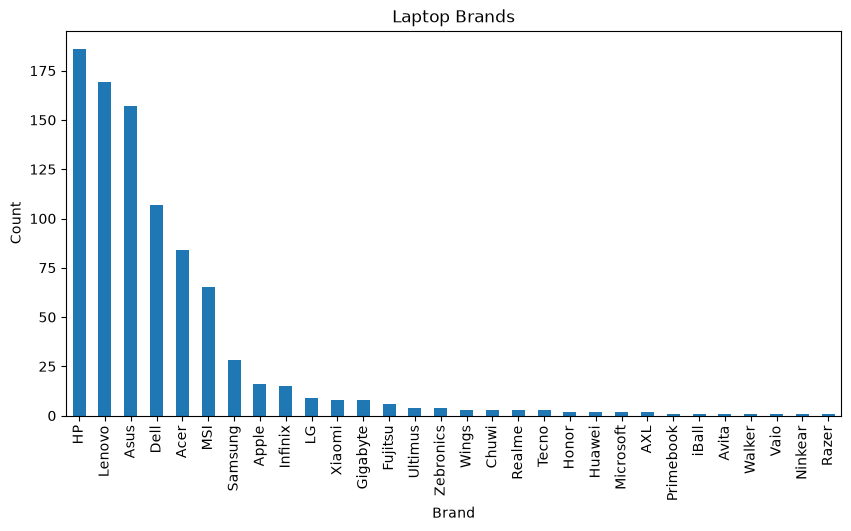

In [10]:
df["brand"].value_counts().plot(kind="bar", figsize=(10,5))
plt.title("Laptop Brands")
plt.xlabel("Brand")
plt.ylabel("Count")
plt.show()

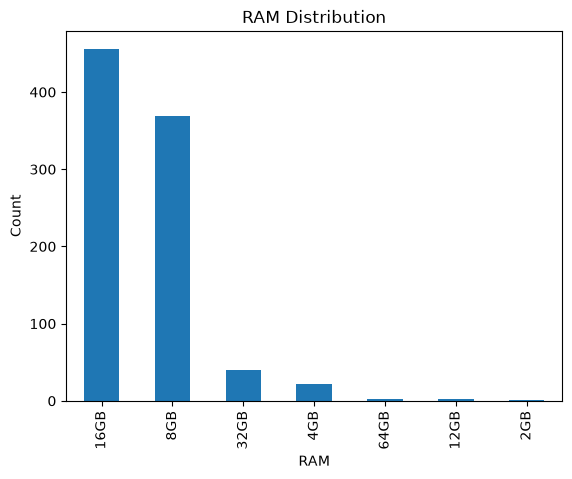

In [11]:
df["Ram"].value_counts().plot(kind="bar")
plt.title("RAM Distribution")
plt.xlabel("RAM")
plt.ylabel("Count")
plt.show()

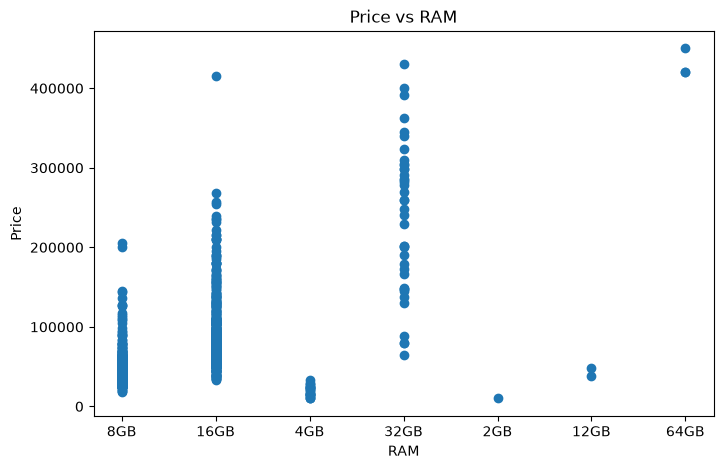

In [12]:
plt.figure(figsize=(8,5))
plt.scatter(df["Ram"], df["price"])
plt.xlabel("RAM")
plt.ylabel("Price")
plt.title("Price vs RAM")
plt.show()

In [13]:
# Remove Duplicate Rows
df = df.drop_duplicates()

# Remove Missing Values
df = df.dropna()

# Check Again
print(df.isnull().sum())
print(df.shape)

Unnamed: 0.1         0
Unnamed: 0           0
brand                0
name                 0
price                0
spec_rating          0
processor            0
CPU                  0
Ram                  0
Ram_type             0
ROM                  0
ROM_type             0
GPU                  0
display_size         0
resolution_width     0
resolution_height    0
OS                   0
warranty             0
dtype: int64
(893, 18)


In [14]:
df.to_csv("Laptop_Cleaned.csv", index=False)

print("Cleaned dataset saved successfully!")

Cleaned dataset saved successfully!
